# 01 · Preparación, chunking y encoders

Laboratorio reproducible para el RAG de derecho colombiano. Los **20 documentos** son los artículos 1–20 del fixture local de la Ley 1581 de 2012. Hay 32 consultas, incluidas paráfrasis y una que requiere dos artículos. La unidad de evaluación es el **artículo**, aunque se buscan chunks. Las etiquetas se usan solo para medir.

**Ejecución:** instalar `numpy pandas matplotlib scikit-learn beautifulsoup4 sentence-transformers faiss-cpu nbformat`; ejecutar de arriba abajo. El primer uso de un encoder puede descargar pesos. `TF-IDF` es control léxico, no un encoder neuronal. Las cifras se generan al ejecutar, nunca están precalculadas. El conjunto es deliberadamente pequeño y de una sola ley: sirve para depurar estrategias; repetir el protocolo con consultas representativas y otras normas antes de adoptar una configuración.

**Diseño experimental:** 19 consultas `dev` eligen chunking y encoder; 13 `test` quedan cerradas hasta el notebook 02. No se usa el texto de las consultas para construir los chunks ni para entrenar embeddings.

In [1]:
from pathlib import Path
import sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

HERE = Path.cwd() / "notebooks" if (Path.cwd() / "notebooks/lab_core.py").exists() else Path.cwd()
if not (HERE / "lab_core.py").exists():
    raise FileNotFoundError("Ejecuta desde la raíz de rag-derecho-colombiano o desde notebooks/")
sys.path.insert(0, str(HERE))
import lab_core as lab
data = lab.load_sample()
docs, queries = data["documents"], data["queries"]
dev = [q for q in queries if q["split"] == "dev"]
test = [q for q in queries if q["split"] == "test"]
print(f"{len(docs)} artículos, {len(dev)} consultas dev, {len(test)} test")

20 artículos, 19 consultas dev, 13 test


## 1. Levantamiento y aplanado

La fuente de esta muestra es texto UTF-8 con artículos y secciones. Cada documento conserva `source_start/source_end`; cada chunk conserva posiciones absolutas para comprobar citas. Para HTML, eliminar navegación y scripts, preservar encabezados y convertir tablas en filas con separadores. Para PDF con capa de texto, extraer por página y revisar orden de lectura. Páginas vacías o escaneadas requieren OCR y control de calidad; no conviene inventar texto. Mantener texto bruto, texto procesado, hash, URL, fecha, jurisdicción, norma, artículo, sección y vigencia verificada. No usar encabezados repetidos, pies, firmas ni preguntas de evaluación como contenido indexable.

La categorización inicial aquí se basa en la estructura de la norma. En el corpus completo se deben preservar áreas, tipo de norma y jurisdicción; una clasificación aprendida solo vale si mejora la recuperación en consultas independientes.

In [2]:
html = "<nav>Menú</nav><h2>Artículo 9</h2><p>Autorización previa del titular.</p><table><tr><th>Campo</th><th>Regla</th></tr><tr><td>Datos</td><td>Consentimiento</td></tr></table>"
print(lab.flatten_html(html))
display(pd.DataFrame([{"doc_id": d["doc_id"], "sección": d["section"], "categoría": lab.category(d), "palabras": len(lab.tokens(d["text"]))} for d in docs]))
source = (HERE.parent / docs[0]["source_file"]).read_text(encoding="utf-8")
assert all(source[d["source_start"]:d["source_end"]] == d["text"] for d in docs)
print("Proveniencia: 20/20 cortes coinciden con la fuente local")

Artículo 9
Autorización previa del titular.
Campo | Regla
Datos | Consentimiento


,doc_id,sección,categoría,palabras
0,art01,"TÍTULO I OBJETO, ÁMBITO DE APLICACIÓN Y DEFINI...",fundamentos,71
1,art02,"TÍTULO I OBJETO, ÁMBITO DE APLICACIÓN Y DEFINI...",fundamentos,343
2,art03,"TÍTULO I OBJETO, ÁMBITO DE APLICACIÓN Y DEFINI...",fundamentos,160
3,art04,TÍTULO II PRINCIPIOS RECTORES,fundamentos,445
4,art05,TÍTULO III CATEGORÍAS ESPECIALES DE DATOS,datos_especiales,94
5,art06,TÍTULO III CATEGORÍAS ESPECIALES DE DATOS,datos_especiales,197
6,art07,TÍTULO III CATEGORÍAS ESPECIALES DE DATOS,datos_especiales,145
7,art08,TÍTULO IV DERECHOS Y CONDICIONES DE LEGALIDAD ...,derechos_tramites,229
8,art09,TÍTULO IV DERECHOS Y CONDICIONES DE LEGALIDAD ...,derechos_tramites,41
9,art10,TÍTULO IV DERECHOS Y CONDICIONES DE LEGALIDAD ...,derechos_tramites,100


Proveniencia: 20/20 cortes coinciden con la fuente local


## 2. Cinco estrategias de chunking

`fijo` usa 90 palabras; `fijo_solape` añade 20 de solape; `oraciones` y `parrafos` empaquetan unidades hasta 110/130 palabras; `jerarquico` usa párrafos y añade sección y artículo al texto indexado. Todas mantienen artículo y posiciones de origen. La referencia explícita al artículo evita que una sección aislada pierda identidad. Si el corpus contiene tablas o artículos largos, se requieren reglas específicas de cada formato y un límite medido con el **tokenizador real** del encoder. Aquí la aproximación por palabras permite comparar la geometría de los chunks.

,estrategia,chunks,palabras_mediana,palabras_p95,cobertura,redundancia,max_palabras,fronteras_logicas
0,fijo,50,90.0,90.0,1.0,0.000,90,0.400
1,fijo_solape,56,90.0,90.0,1.0,0.151,90,0.366
2,oraciones,45,85.0,106.4,1.0,0.000,110,1.000
3,parrafos,38,100.0,127.3,1.0,0.000,130,1.000
4,jerarquico,38,100.0,127.3,1.0,0.000,130,1.000


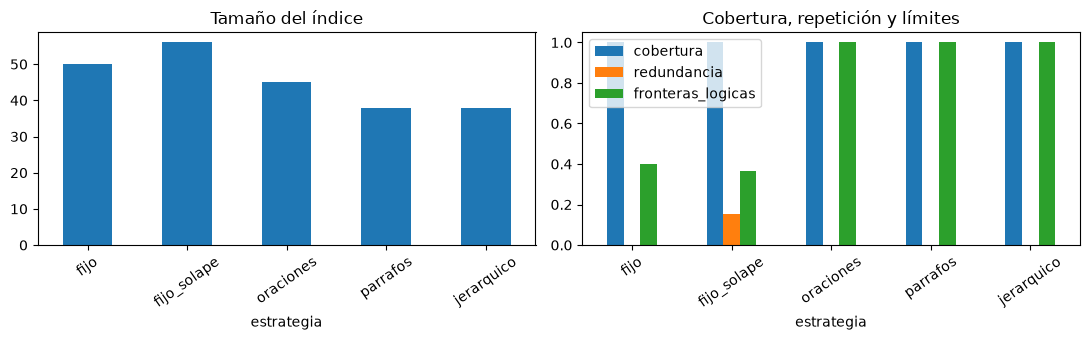

,estrategia,muestra
0,fijo,Artículo 2°. Ámbito de aplicación. Los princip...
1,fijo_solape,Artículo 2°. Ámbito de aplicación. Los princip...
2,oraciones,Artículo 2°. Ámbito de aplicación. Los princip...
3,parrafos,Artículo 2°. Ámbito de aplicación. Los princip...
4,jerarquico,Artículo 2°. Ámbito de aplicación. Los princip...


In [3]:
strategies = list(lab.STRATEGIES)
chunk_sets = {s: lab.make_chunks(docs, s) for s in strategies}
diagnostics = pd.DataFrame([{"estrategia": s, **lab.chunk_diagnostics(docs, c)} for s, c in chunk_sets.items()])
for s, chunks in chunk_sets.items():
    assert all(source[c["start"]:c["end"]] == c["text"] for c in chunks)
display(diagnostics.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
diagnostics.plot.bar(x="estrategia", y="chunks", ax=axes[0], legend=False, title="Tamaño del índice")
diagnostics.plot.bar(x="estrategia", y=["cobertura", "redundancia", "fronteras_logicas"], ax=axes[1], title="Cobertura, repetición y límites")
for ax in axes: ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()
display(pd.DataFrame([{"estrategia": s, "muestra": chunk_sets[s][1]["text"][:180].replace("\n", " ")}
                      for s in strategies]))

## 3. Comparar encoders y recuperación inicial

Por defecto se comparan TF-IDF y `multilingual-e5-base`; activar BGE-M3 para la prueba completa (descarga y CPU más costosos). E5 usa los prefijos `query:` y `passage:`; todos los vectores se normalizan y se comparan por coseno. Se registra tiempo de construcción, tiempo de codificar consultas, dimensión y memoria vectorial. **Recall@k, MRR@5 y nDCG@5** se calculan sobre artículos deduplicados; el ranking inicial se obtiene a nivel chunk. La selección en `dev` pondera Recall@3 y MRR@5, con desempate por menor memoria.

In [ ]:
INCLUIR_BGE_M3 = False 
encoder_names = ["tfidf", "intfloat/multilingual-e5-base"] + (["BAAI/bge-m3"] if INCLUIR_BGE_M3 else [])
rows, cache = [], {}
for strategy, chunks in chunk_sets.items():
    texts = [c["indexed_text"] for c in chunks]
    for name in encoder_names:
        t0 = time.perf_counter()
        enc = lab.Encoder(name)
        vectors = enc.fit_documents(texts)
        build_s = time.perf_counter() - t0
        if enc.model is None:
            token_p95, truncation_rate = np.nan, np.nan
        else:
            payload = ["passage: " + text for text in texts] if "e5" in name else texts
            lengths = [len(ids) for ids in enc.model.tokenizer(payload, truncation=False)["input_ids"]]
            token_p95 = float(np.percentile(lengths, 95))
            truncation_rate = float(np.mean(np.array(lengths) > enc.model.max_seq_length))
        t0 = time.perf_counter()
        qvectors = enc.queries([q["question"] for q in queries])
        query_ms = 1000 * (time.perf_counter() - t0) / len(queries)
        dev_pos = [i for i, q in enumerate(queries) if q["split"] == "dev"]
        ranked = lab.rank_exact(vectors, qvectors[dev_pos], len(chunks))
        score = lab.metrics(ranked, chunks, dev)
        key = (strategy, name)
        cache[key] = (chunks, vectors, qvectors)
        rows.append({"estrategia": strategy, "encoder": name, **score,
                     "construcción_s": build_s, "consulta_encoder_ms": query_ms,
                     "dim": vectors.shape[1], "vectores_MiB": vectors.nbytes / 2**20,
                     "tokens_p95": token_p95, "fraccion_truncada": truncation_rate})
results = pd.DataFrame(rows)
display(results.sort_values(["recall@3", "mrr@5"], ascending=False).round(3))

C:\Users\nrir\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4883.95it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4583.59it/s]

...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4300.52it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4233.81it/s]

,estrategia,encoder,recall@1,recall@3,recall@5,mrr@5,ndcg@5,construcción_s,consulta_encoder_ms,dim,vectores_MiB,tokens_p95,fraccion_truncada
5,oraciones,intfloat/multilingual-e5-base,0.684,0.868,0.974,0.793,0.834,7.262,1.806,768,0.132,162.00,0.0
7,parrafos,intfloat/multilingual-e5-base,0.579,0.868,0.974,0.743,0.797,7.426,1.764,768,0.111,196.15,0.0
9,jerarquico,intfloat/multilingual-e5-base,0.737,0.842,0.868,0.791,0.809,7.228,1.747,768,0.111,223.05,0.0
1,fijo,intfloat/multilingual-e5-base,0.474,0.842,0.921,0.655,0.720,37.065,1.727,768,0.146,146.30,0.0
3,fijo_solape,intfloat/multilingual-e5-base,0.579,0.789,0.868,0.696,0.738,7.280,1.768,768,0.164,149.50,0.0
6,parrafos,tfidf,0.500,0.605,0.684,0.581,0.600,0.015,0.068,2666,0.386,NaN,NaN
8,jerarquico,tfidf,0.500,0.605,0.684,0.581,0.598,0.015,0.068,2708,0.393,NaN,NaN
2,fijo_solape,tfidf,0.474,0.605,0.684,0.554,0.586,0.019,0.078,2698,0.576,NaN,NaN
4,oraciones,tfidf,0.474,0.605,0.684,0.548,0.586,0.021,0.104,2669,0.458,NaN,NaN
0,fijo,tfidf,0.474,0.553,0.684,0.541,0.579,2.353,0.083,2677,0.511,NaN,NaN


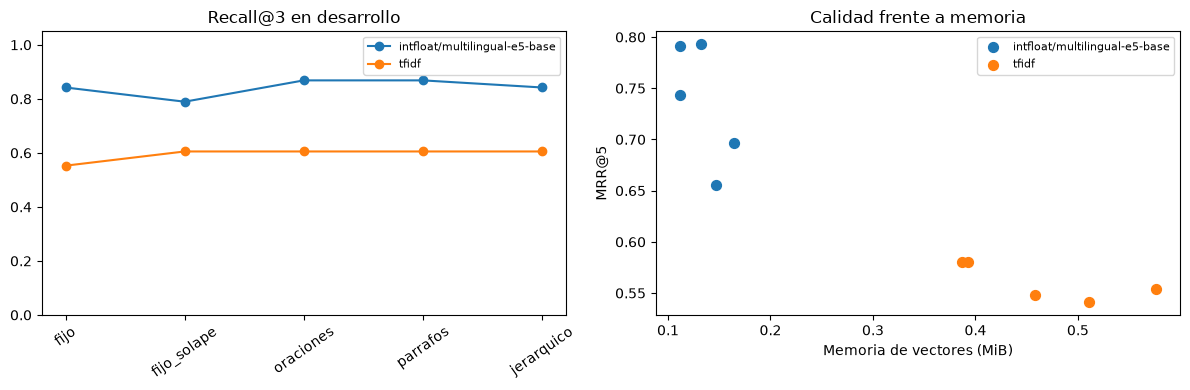

Elección exploratoria (solo dev): {'estrategia': 'oraciones', 'encoder': 'intfloat/multilingual-e5-base', 'utilidad_dev': 0.8382456140350877}


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, part in results.groupby("encoder"):
    axes[0].plot(part["estrategia"], part["recall@3"], marker="o", label=name)
axes[0].set(title="Recall@3 en desarrollo", ylim=(0, 1.05)); axes[0].tick_params(axis="x", rotation=35); axes[0].legend(fontsize=8)
for name, part in results.groupby("encoder"):
    axes[1].scatter(part["vectores_MiB"], part["mrr@5"], s=50, label=name)
axes[1].set(xlabel="Memoria de vectores (MiB)", ylabel="MRR@5", title="Calidad frente a memoria")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
results["utilidad_dev"] = .6 * results["recall@3"] + .4 * results["mrr@5"]
winner = results.sort_values(["utilidad_dev", "vectores_MiB", "construcción_s"], ascending=[False, True, True]).iloc[0]
print("Elección exploratoria (solo dev):", winner[["estrategia", "encoder", "utilidad_dev"]].to_dict())

## 4. Exportar la base de conocimiento experimental

El artefacto conserva alineación exacta entre fila vectorial y metadatos del chunk. El notebook 02 leerá **la misma configuración** y usará el mismo encoder para codificar consultas. Para el corpus completo: sustituir el fixture por manifiestos reales, conservar URL/hash/offsets, comprobar vigencia, crear un conjunto de juicios por dominio y congelar el conjunto de prueba antes de ajustar.

In [6]:
out = HERE / "artefactos_lab"
out.mkdir(exist_ok=True)
key = (winner["estrategia"], winner["encoder"])
chosen_chunks, chosen_vectors, chosen_qvectors = cache[key]
(out / "chunks.json").write_text(json.dumps(chosen_chunks, ensure_ascii=False, indent=2), encoding="utf-8")
(out / "config.json").write_text(json.dumps({"strategy": key[0], "encoder": key[1], "evaluated_encoders": encoder_names,
                                        "n_docs": len(docs), "n_chunks": len(chosen_chunks)}, ensure_ascii=False, indent=2), encoding="utf-8")
np.savez_compressed(out / "vectors.npz", documents=chosen_vectors, queries=chosen_qvectors)
results.to_csv(out / "comparacion_encoder_dev.csv", index=False)
print("Guardado en", out)
print("No abrir test en este notebook; se reserva para 02.")

Guardado en C:\Users\nrir\Desktop\dev\AI WEEK\rag-derecho-colombiano\notebooks\artefactos_lab
No abrir test en este notebook; se reserva para 02.
